In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [22]:
DISTRICT_POP = {"kasungu":  842953 , "mchinji": 602305, 
                "dowa": 772569, "all": 17563749, 
                "karonga": 1, "chitipa": 1}

def plot_policy_analysis(district, pool, policy_order, policy_colors):
    
    CONVERSION_FACTOR = DISTRICT_POP[district] * 148.83
    # Read the CSV file into a DataFrame
    df = pd.read_csv("results/{}_pool={}.csv".format(district, pool))

    # Sort the DataFrame by "unconditional_tolerance"
    df_sorted = df.sort_values(by='unconditional_tolerance')
    
    df_sorted["policy"] = pd.Categorical(df_sorted["policy"], categories=policy_order)
    df_sorted.sort_values("policy", inplace=True)

    # Group the data by policy type
    grouped = df_sorted.groupby('policy')

    # Determine the minimum and maximum values of the x-axis
    x_min = min(df['unconditional_tolerance'].min(), df['post_transfer_poverty_rate'].min()) - 0.02
    x_max = max(df['unconditional_tolerance'].max(), df['post_transfer_poverty_rate'].max()) + 0.02

    # Create a figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Plot policy_cost vs. tolerance for each policy type
    for i, (name, group) in enumerate(grouped):
            axs[0].plot(group['unconditional_tolerance'], group['policy_cost'] * CONVERSION_FACTOR, marker='o', label=name, c=policy_colors[i])
    axs[0].set_xlabel('Unconditional Tolerance')
    axs[0].set_ylabel('Policy Cost')
    axs[0].set_title('Policy Cost vs. Unconditional Tolerance')
    axs[0].legend()
    axs[0].set_xlim(x_min, x_max)

    # Plot policy_cost vs. post_transfer_poverty_rate by policy type
    for i, (name, group) in enumerate(grouped):
            axs[1].plot(group['post_transfer_poverty_rate'], group['policy_cost']* CONVERSION_FACTOR, marker='o', label=name, c=policy_colors[i])

    # Add labels and title
    axs[1].set_xlabel('Post-Transfer Poverty Rate')
    axs[1].set_ylabel('Policy Cost')
    axs[1].set_title('Policy Cost vs. Post-Transfer Poverty Rate')
    axs[1].legend()
    axs[1].set_xlim(x_min, x_max)

        # Plot post_transfer_poverty_rate vs. tolerance for each policy type
    for i, (name, group) in enumerate(grouped):
            axs[2].plot(group['unconditional_tolerance'], group['post_transfer_poverty_rate'], marker='o', label=name, c=policy_colors[i])

    axs[2].plot(group["unconditional_tolerance"], group["unconditional_tolerance"], color='black', linestyle='--')

    axs[2].set_xlabel('Unconditional Tolerance')
    axs[2].set_ylabel('Post-Transfer Poverty Rate')
    axs[2].set_title('Post-Transfer Poverty Rate vs. Unconditional Tolerance')
    axs[2].legend()

    plt.suptitle("Malawi District: {}".format(district))
    # Display the plot
    plt.tight_layout()
    plt.savefig("figs/{}.pdf".format(district))
    plt.show()

/tmp/ipykernel_2215769/2373099975.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_sorted.groupby('policy')


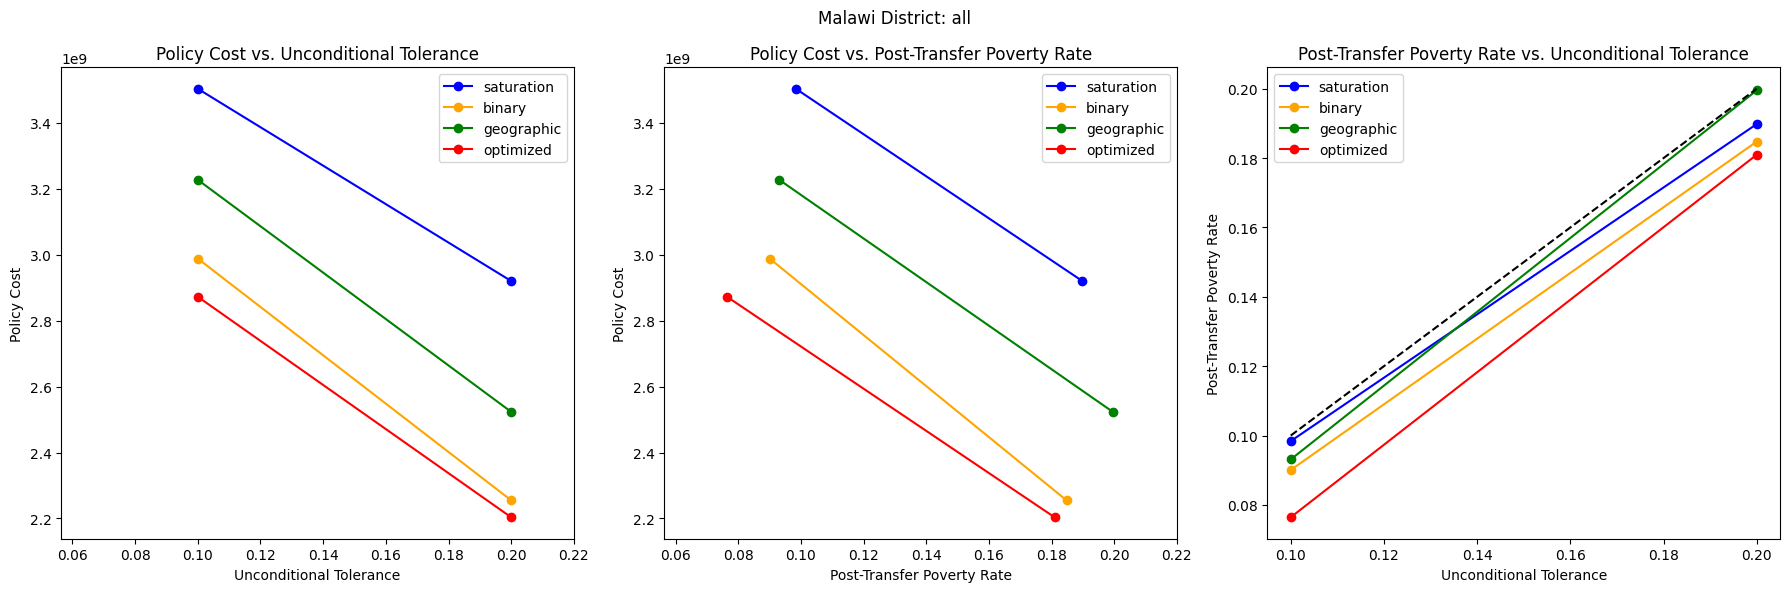

/tmp/ipykernel_2215769/2373099975.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_sorted.groupby('policy')


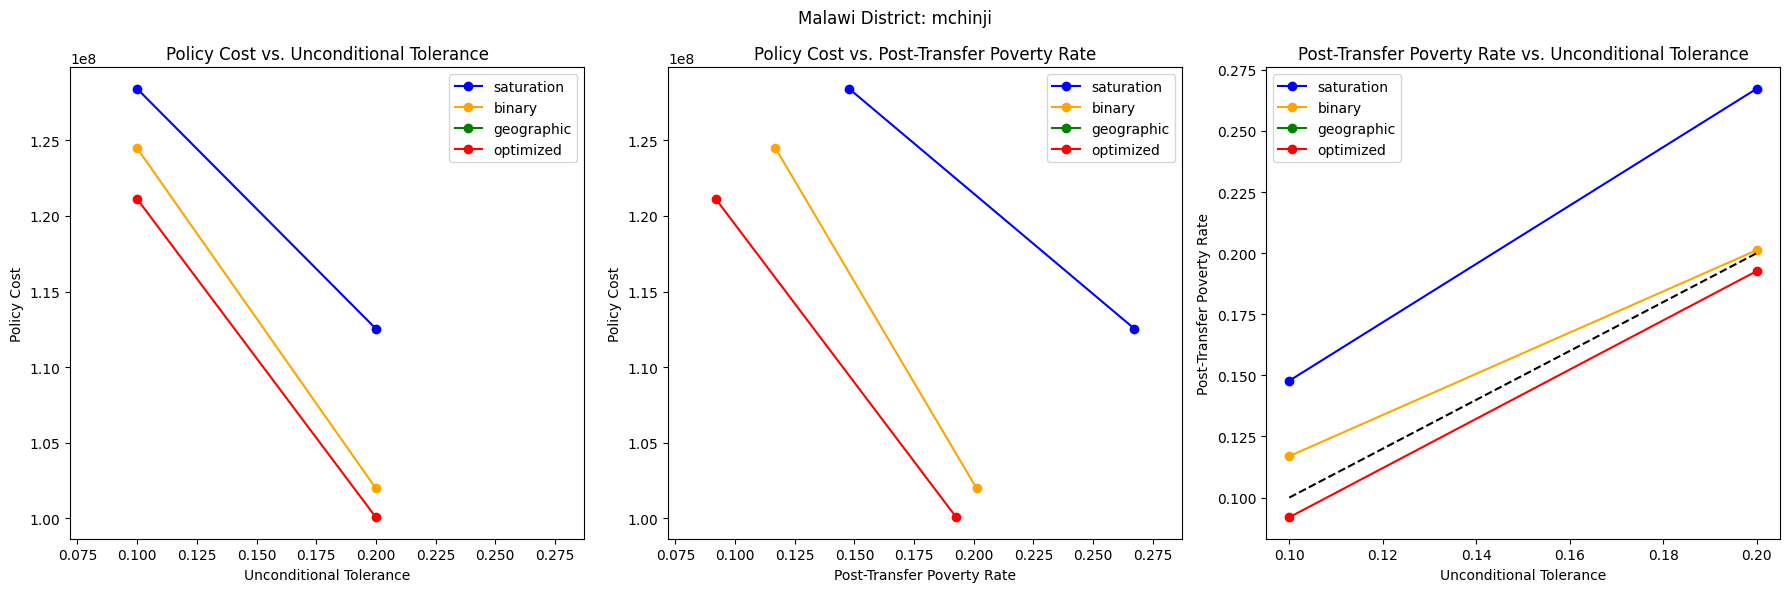

/tmp/ipykernel_2215769/2373099975.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_sorted.groupby('policy')


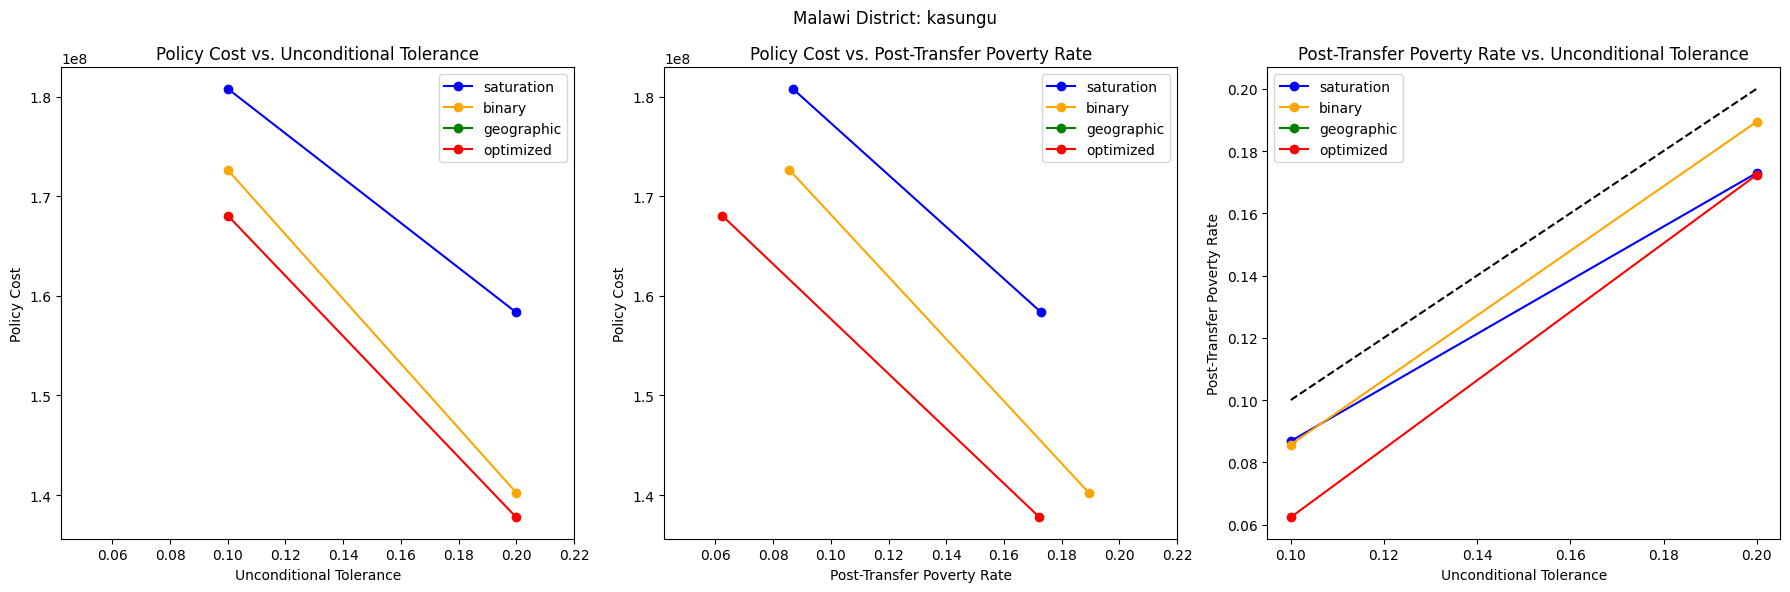

/tmp/ipykernel_2215769/2373099975.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_sorted.groupby('policy')


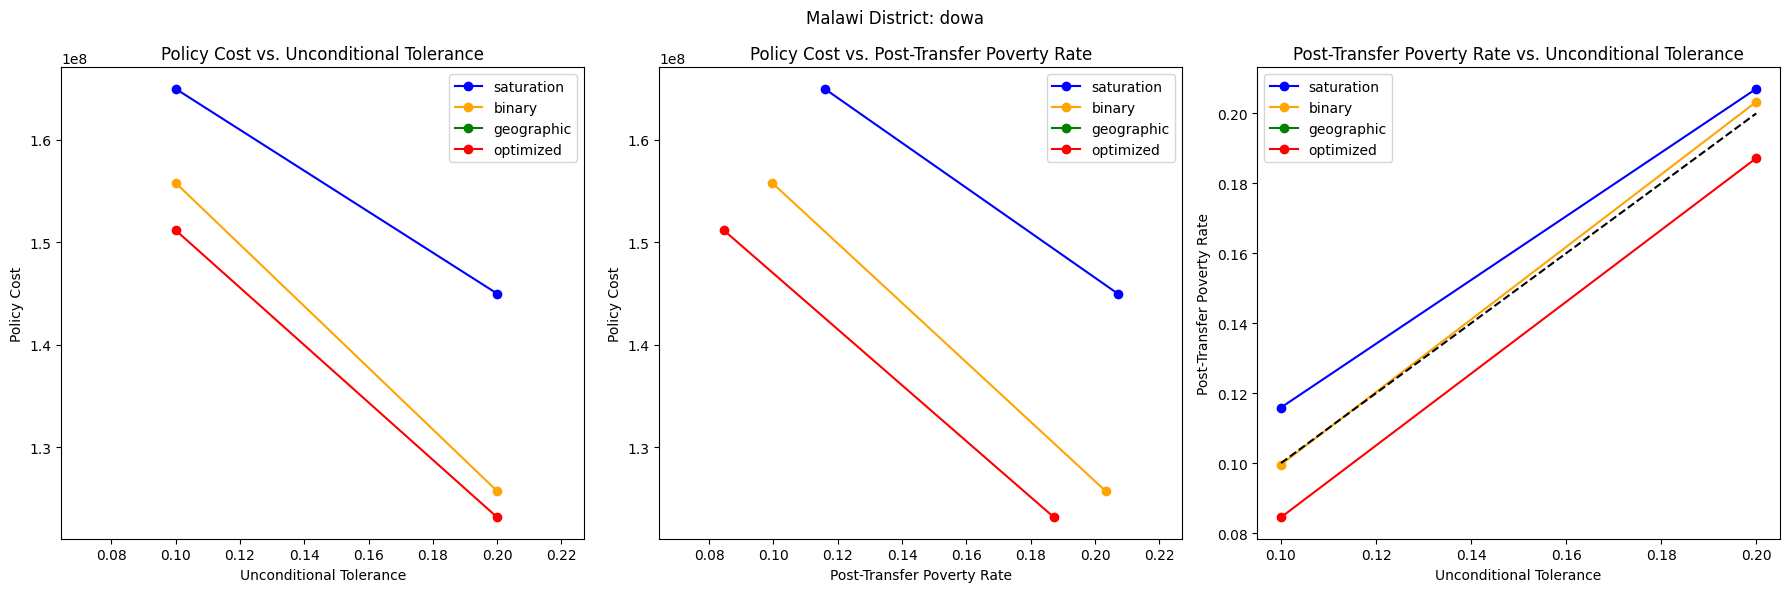

In [23]:
policy_order = ["saturation", "binary", "geographic", "optimized"]
policy_colors = ["blue", "orange", "green", "red"]
for district in ["all", "mchinji", "kasungu", "dowa"]:
        plot_policy_analysis(district, pool="central", policy_order=policy_order, policy_colors=policy_colors)

/tmp/ipykernel_2215769/2373099975.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_sorted.groupby('policy')


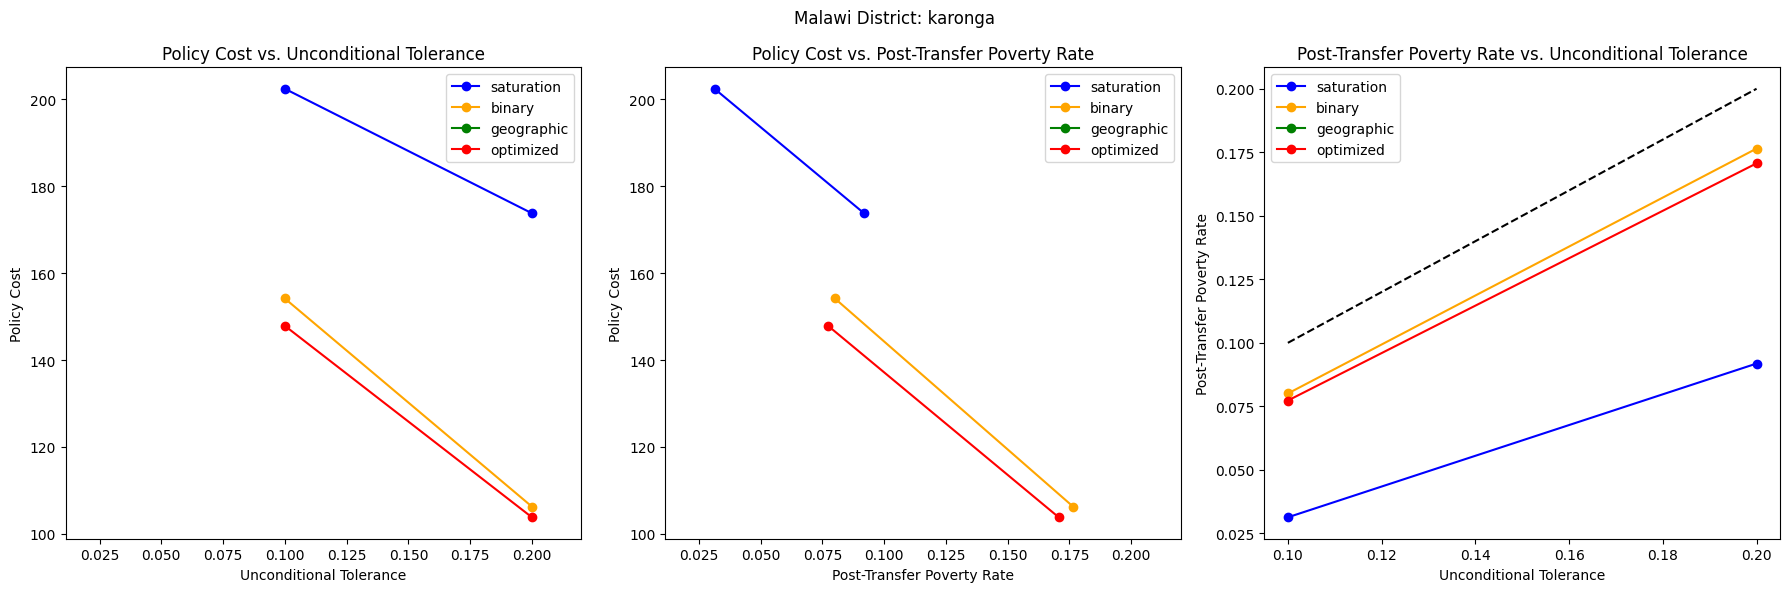

/tmp/ipykernel_2215769/2373099975.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_sorted.groupby('policy')


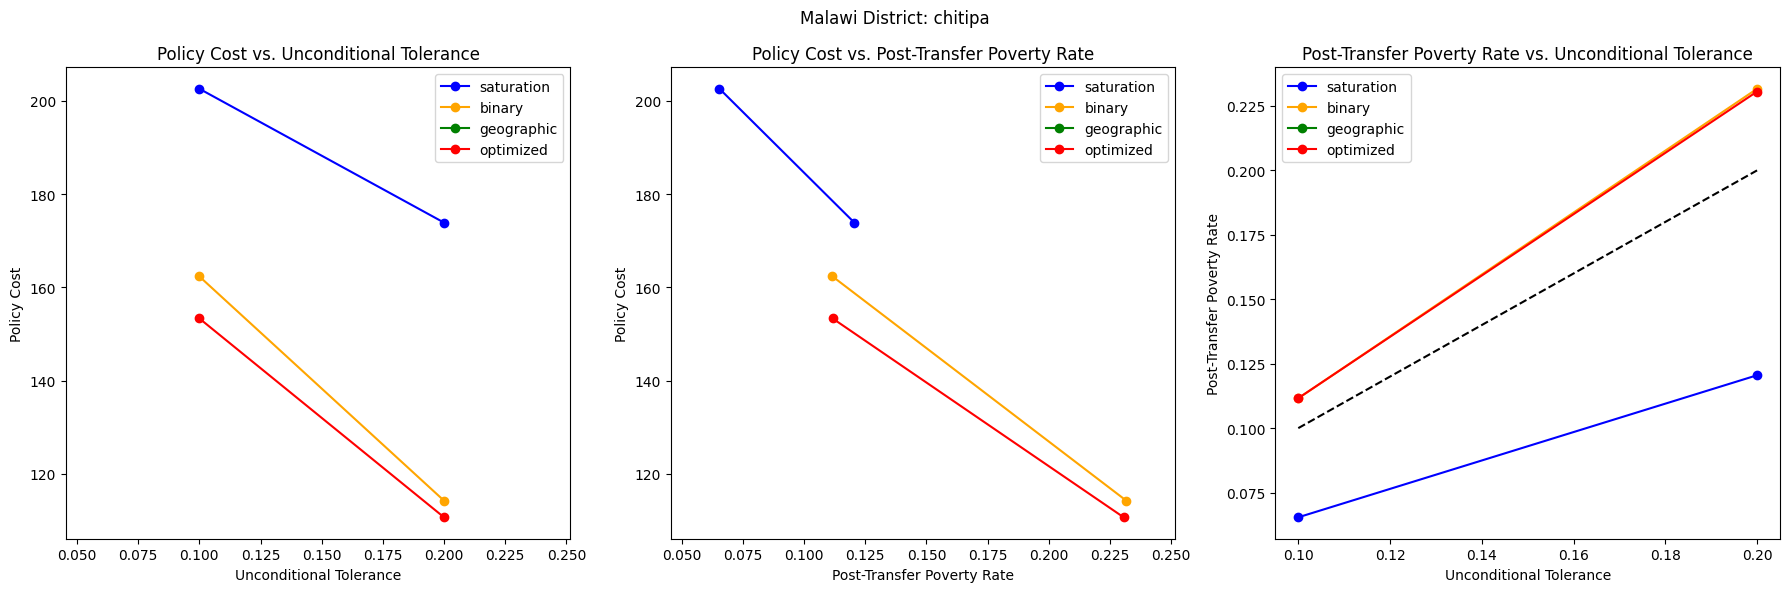

In [24]:
policy_order = ["saturation", "binary", "geographic", "optimized"]
policy_colors = ["blue", "orange", "green", "red"]
for district in ["karonga", "chitipa"]:
        plot_policy_analysis(district, pool="rural", policy_order=policy_order, policy_colors=policy_colors)

In [2]:
from data_loaders import get_datasets


get_datasets("mchinji", "rural", None)

/zfs/gsb/intermediate-yens/rsahoo/poverty/gd/data_loaders.py:104: DtypeWarning: Columns (10,20,24,26,28,31,33,37,39,40,43,44,45,46,47,49,50,52,53,55,58,60,64,72,73,80,82,83,84,85,87,89,90,98,151,164,166,168,170,171,172,175,176,187,190) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH_TO_DATA)


> /zfs/gsb/intermediate-yens/rsahoo/poverty/gd/data_loaders.py(110)get_district_dataset()
    108 
    109     # Drop rows of dataframe that missing outcome values
--> 110     df.dropna(axis=0, subset="rexpagg", inplace=True)
    111     df = df.reset_index()
    112 

array(['Chitipa', 'Karonga', 'Nkhatabay', 'Rumphi', 'Mzimba', 'Likoma',
       'Mzuzu City', 'Kasungu', 'Nkhotakota', 'Ntchisi', 'Dowa', 'Salima',
       'Lilongwe', 'Mchinji', 'Dedza', 'Ntcheu', 'Lilongwe City',
       'Mangochi', 'Machinga', 'Zomba', 'Chiradzulu', 'Blantyre',
       'Mwanza', 'Thyolo', 'Mulanje', 'Phalombe', 'Chikwawa', 'Nsanje',
       'Balaka', 'Neno', 'Zomba City', 'Blantyre City'], dtype=object)
array(['Chitipa', 'Karonga', 'Nkhatabay', 'Rumphi', 'Mzimba', 'Likoma',
       'Mzuzu City', 'Kasungu', 'Nkhotakota', 'Ntchisi', 'Dowa', 'Salima',
       'Lilongwe', 'Mchinji', 'Dedza', 'Ntcheu', 'Lilongwe City',
       'Mangochi', 'Machinga', 'Zomba', 'Chiradzulu', 'Blantyre',
       'Mwanza', 'Thyolo', 'M

/zfs/gsb/intermediate-yens/rsahoo/poverty/gd/data_loaders.py:41: DtypeWarning: Columns (10,20,24,26,28,31,33,37,39,40,43,44,45,46,47,49,50,52,53,55,58,60,64,72,73,80,82,83,84,85,87,89,90,98,151,164,166,168,170,171,172,175,176,187,190) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH_TO_DATA)


Index([], dtype='object')


((array([], shape=(9006, 0), dtype=float64),
  array([0.92027154, 1.55950186, 0.86248553, ..., 1.94283856, 2.0473776 ,
         0.96884157]),
  array([93.71939961, 93.71939961, 93.71939961, ..., 77.52041992,
         77.52041992, 77.52041992])),
 (array([], shape=(352, 0), dtype=float64),
  array([ 2.73423036,  2.02011746,  4.84432922,  1.06756707,  3.47910487,
          0.80636225,  6.24137262,  1.14113806,  2.94884551,  3.95349898,
          1.48760361,  1.58607252,  2.46482497,  2.65408176,  1.23577624,
          1.93177218,  1.16074427,  0.88837873,  2.01882141,  1.30123956,
          2.76206772,  1.21521597,  2.41811671,  1.03139985,  3.3684488 ,
          1.05431513,  2.44280359,  1.18337612,  3.32817331,  4.3310118 ,
          1.29820565,  2.51431732,  0.51434214,  3.33418817,  0.69680881,
          1.70937913,  0.60372048,  1.87587196,  1.52798804,  4.75185818,
          5.35776638,  0.71020438,  0.84093588,  1.13936401,  2.35008589,
          0.64190316,  1.95309257,  0.369882